<a href="https://colab.research.google.com/github/aycakrk/DI725_Ayca/blob/main/Final_Project/phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip "/content/drive/MyDrive/RISCM.zip" -d "/content"

Streaming output truncated to the last 5000 lines.
  inflating: /content/resized/RSICD_4364.jpg  
  inflating: /content/resized/NWPU_18440.jpg  
  inflating: /content/resized/NWPU_129.jpg  
  inflating: /content/resized/NWPU_19322.jpg  
  inflating: /content/resized/RSICD_3101.jpg  
  inflating: /content/resized/UCM_2077.jpg  
  inflating: /content/resized/NWPU_10992.jpg  
  inflating: /content/resized/NWPU_10941.jpg  
  inflating: /content/resized/NWPU_19048.jpg  
  inflating: /content/resized/UCM_1535.jpg  
  inflating: /content/resized/NWPU_22896.jpg  
  inflating: /content/resized/NWPU_15332.jpg  
  inflating: /content/resized/RSICD_7475.jpg  
  inflating: /content/resized/NWPU_24431.jpg  
  inflating: /content/resized/NWPU_25180.jpg  
  inflating: /content/resized/RSICD_1536.jpg  
  inflating: /content/resized/NWPU_18103.jpg  
  inflating: /content/resized/NWPU_906.jpg  
  inflating: /content/resized/NWPU_11526.jpg  
  inflating: /content/resized/NWPU_22481.jpg  
  inflating: /con



---



---



In [ ]:
# Örnek: captions.csv'yi oku
import pandas as pd
df = pd.read_csv('captions.csv')
df.head()


,source,split,image,caption_1,caption_2,caption_3,caption_4,caption_5
0,NWPU,test,NWPU_31430.jpg,A gray plane on the runway and the lawn beside .,A grey plane is on the runway by the lawn .,There is an airplane on the runway with a larg...,A plane is parked on the runway next to the gr...,There is a plane on the runway beside the grass .
1,NWPU,test,NWPU_31431.jpg,Three small planes parked in a line on the air...,"There are four aircraft on the open ground, Th...",There are many planes of different sizes in a ...,Four planes are parked on the runway .,Four planes of different sizes were on the mar...
2,NWPU,test,NWPU_31432.jpg,A plane parked in a line on the airport with s...,A white plane was parked on the instruction li...,An airplane parked in an open area with many c...,A plane is parked on the open space .,There is 1 plane on the ground marked .
3,NWPU,test,NWPU_31433.jpg,A small plane and a big plane parked next to b...,A white plane and a gray plane parked at the b...,Two planes of different sizes are neatly parke...,A large plane and a small plane are parked nea...,Two planes are on the marked ground .
4,NWPU,test,NWPU_31434.jpg,Two planes parked next to boarding bridges .,Two aircraft were parked at the departure gates .,Two planes of different sizes are neatly parke...,Two planes are parked next to the terminal .,Two planes are on the marked ground .


Split data according to the csv split column

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()


In [ ]:
# length evaluation
n_train = len(train_df)
n_val   = len(val_df)
n_test  = len(test_df)
total   = n_train + n_val + n_test

print(f"Train: {n_train} ({n_train/total:.2%})")
print(f"Test:  {n_test}  ({n_test/total:.2%})")
print(f"Val:   {n_val}   ({n_val/total:.2%})")


Train: 35614 (79.99%)
Test:  4454  (10.00%)
Val:   4453   (10.00%)


In [ ]:
# compare/ check if its same with the document
counts = df["split"].value_counts()

print(counts)

split
train    35614
test      4454
val       4453
Name: count, dtype: int64




---


---





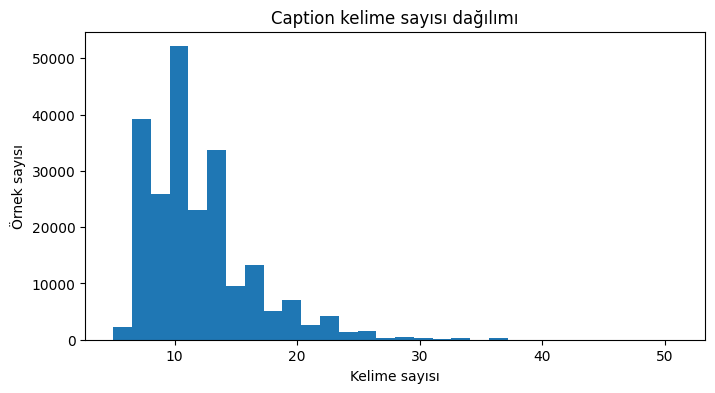

Top 10 kelime: [('.', 218293), ('the', 205462), ('a', 117729), ('are', 110696), ('and', 100620), ('is', 77969), ('there', 73834), ('of', 69650), ('some', 62068), ('many', 61772)]
Unique kelime sayısı: 4914
Örnek unique kelimeler: ['a', 'gray', 'plane', 'on', 'the', 'runway', 'and', 'lawn', 'beside', '.', 'grey', 'is', 'by', 'there', 'an', 'airplane', 'with', 'large', 'parked', 'next', 'to', 'grass', 'three', 'small', 'planes', 'in', 'line', 'airport', 'big', 'behind', 'them', 'are', 'four', 'aircraft', 'open', 'ground,', 'largest', 'of', 'which', 'times', 'as', 'smallest', 'one', 'many', 'different', 'sizes', 'clearing', 'were', 'marked', 'ground']
Sadece 1 kez geçen kelime sayısı: 1385
Örnek hapax legomena: ['locations', 'blue-tailed', 'tenantless', 'triagonal', 'untenanted', 'heterogeneous', 'unclean', 'lawns,with', 'river,with', 'tones', 'level', 'traced', 'darkened', 'spiritual', 'funnel-shaped', 'violet', 'cracked', 'parallel,', 'corners,', 'ball-shaped', 'shrine', 'five-ball', 'g

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1) captions.csv'ü zaten okuduğumuz df üzerinden alıyoruz
#    Eğer df yoksa önce:
# df = pd.read_csv('/content/risc_dataset/captions.csv')

# 2) Tüm caption_1…caption_5 değerlerini tek bir diziye indir
all_caps = df[[f"caption_{i}" for i in range(1, 6)]].values.flatten()

# 3) Caption başına kelime sayısını hesapla
lengths = [len(str(c).split()) for c in all_caps]

# 4) Histogram çiz
plt.figure(figsize=(8,4))
plt.hist(lengths, bins=30)
plt.title("Caption kelime sayısı dağılımı")
plt.xlabel("Kelime sayısı")
plt.ylabel("Örnek sayısı")
plt.show()

# 5) Kelime frekanslarını say
words = " ".join(all_caps).lower().split()
vocab = Counter(words)

# 6) Top 10 en sık kelime
print("Top 10 kelime:", vocab.most_common(10))

# 7) Unique kelimeler listesi
unique_words = list(vocab.keys())
print("Unique kelime sayısı:", len(unique_words))
print("Örnek unique kelimeler:", unique_words[:50])

# Hapax legomena: sadece 1 kez geçen kelimeler
hapaxes = [w for w,c in vocab.items() if c == 1]
print("Sadece 1 kez geçen kelime sayısı:", len(hapaxes))
print("Örnek hapax legomena:", hapaxes[:50])





---



---



are there any missing images?

In [ ]:
img_dir = '/content/resized'
all_images = set(os.listdir(img_dir))
df_images  = set(df['image'].unique())

missing = sorted(list(df_images - all_images))
if missing:
    print(f"Eksik {len(missing)} dosya var. Örnekler:", missing[:10])
else:
    print("Tüm caption’daki image isimleri klasörde bulundu.")


Tüm caption’daki image isimleri klasörde bulundu.


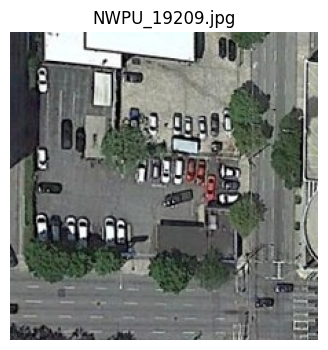

  • caption_1: The parking lot with some parked cars is surrounded by some trees .
  • caption_2: Six rows of cars were parked in the parking lot .
  • caption_3: The parking lot is next to some buildings and trees .
  • caption_4: There are many trees beside the parking lot .
  • caption_5: There are  some green trees beside the parking lot at the corner .

--------------------------------------------------



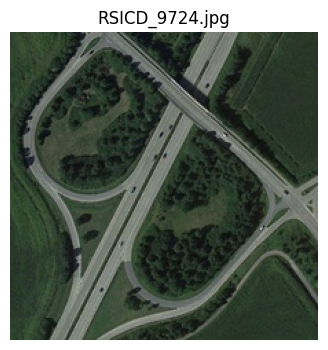

  • caption_1: it is road and lawn .
  • caption_2: it is gray road and green lawn .
  • caption_3: many green trees and meadows are near a viaduct .
  • caption_4: many green trees and meadows are near a viaduct .
  • caption_5: it is road and lawn .

--------------------------------------------------



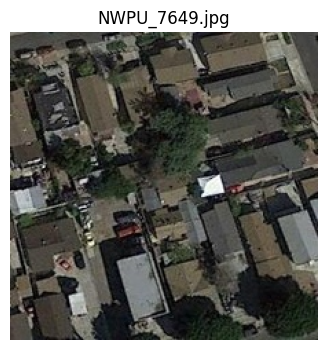

  • caption_1: A dense residential area with lots of houses next to each other is surrounded by some roads .
  • caption_2: The residential area is ringed by several roads .
  • caption_3: There are many roads and neatly arranged houses and trees and many vehicles in densely populated areas .
  • caption_4: The dense residential is next to some trees and cars .
  • caption_5: There are many brown and black buildings on dense residential area .

--------------------------------------------------



In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

n_samples = 3
samples = df.sample(n_samples)

for idx, row in samples.iterrows():
    img_path = os.path.join(img_dir, row['image'])
    img = Image.open(img_path).convert("RGB")

    # show image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{row['image']}")
    plt.show()

    # show 5 caption for each
    for i in range(1,6):
        print(f"  • caption_{i}: {row[f'caption_{i}']}")
    print("\n" + "-"*50 + "\n")




---



---



In [ ]:
!pip install huggingface_hub


In [ ]:
from huggingface_hub import notebook_login
notebook_login()  # karşınıza çıkan kutuya HF Access Token'ınızı yapıştırın


In [ ]:
from transformers import AutoProcessor, AutoModelForImageTextToText

model_name = "google/paligemma-3b-pt-224"

# 1. Girişleri hem görsel hem de metin için hazırlayan processor
processor = AutoProcessor.from_pretrained(
    model_name,
    use_auth_token=True
)

# 2. “Image-to-Text” görevine uygun model
model = AutoModelForImageTextToText.from_pretrained(
    model_name,
    use_auth_token=True
)


/usr/local/lib/python3.11/dist-packages/transformers/models/auto/processing_auto.py:243: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]



---



---



zero-shot trial to see if the model is working

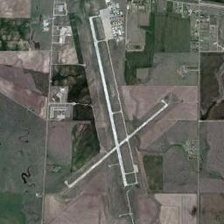

⏳ Generating caption for NWPU_0.jpg…


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


> NWPU_0.jpg → 
map of the airport



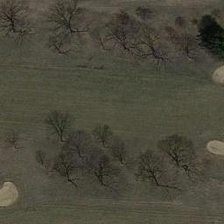

⏳ Generating caption for NWPU_10001.jpg…


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


> NWPU_10001.jpg → 
aerial view of golf course



In [ ]:
import torch
from PIL import Image
from IPython.display import display      # <- unutma


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

sample_images = [
    "/content/resized/NWPU_0.jpg",
    "/content/resized/NWPU_10001.jpg",
]

for img_path in sample_images:
    img = Image.open(img_path).convert("RGB")

    # 1) Önce resim göster
    display(img)
    print(f"⏳ Generating caption for {os.path.basename(img_path)}…", flush=True)

    # 2) Sonra caption üret
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            num_beams=3,
            early_stopping=True
        )

    # 3) Caption'ı yazdır
    caption = processor.decode(outputs[0], skip_special_tokens=True)
    print(f"> {os.path.basename(img_path)} → {caption}\n")


More kapsamlı zer-shot (for all)

In [ ]:
!pip install evaluate transformers tqdm wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.6 MB/s eta 0:00:00


In [ ]:
!pip install rouge_score

In [ ]:
!pip install pycocoevalcap

In [ ]:
import os
from PIL import Image
from transformers import pipeline
from tqdm.auto import tqdm
import evaluate
import wandb
from pycocoevalcap.cider.cider import Cider
import pandas as pd

# 0) W&B oturumunu başlat
wandb.init(project="DI725_FinalProject", name="zero_shot_eval")

# 1) Pipeline’ı kur
pipe = pipeline(
    "image-text-to-text",
    model="google/paligemma-3b-pt-224",
    use_auth_token=True,
    device=0   # GPU’sanız 0; CPU için -1
)

# 2) Val set paths ve 5 referans
img_dir    = "/content/resized"
val_paths  = [os.path.join(img_dir, p) for p in val_df["image"].tolist()]
references = val_df[[f"caption_{i}" for i in range(1,6)]].values.tolist()

# 3) Tahminleri al
preds = []
for img_path in tqdm(val_paths):
    image = Image.open(img_path).convert("RGB")
    out = pipe(images=image, text="", max_length=64, num_beams=3)
    preds.append(out[0]["generated_text"])

# 4) BLEU / METEOR / ROUGE-L hesapla (5 referans)
bleu   = evaluate.load("bleu")
meteor = evaluate.load("meteor")
rouge  = evaluate.load("rouge")

# Çoklu referans olarak tüm listeyi veriyoruz:
bleu_score   = bleu.compute(predictions=preds, references=references)["bleu"]
meteor_score = meteor.compute(predictions=preds, references=references)["meteor"]
rouge_score  = rouge.compute(predictions=preds, references=references)["rougeL"]

# 5) CIDEr hesapla (pycocoevalcap)
refs_dict  = {i: references[i] for i in range(len(references))}
preds_dict = {i: [preds[i]]       for i in range(len(preds))}

cider_scorer = Cider()
cider_score, _ = cider_scorer.compute_score(refs_dict, preds_dict)

# 6) Metrics’i topla ve W&B’e logla
metrics = {
    "zero_shot/bleu":    bleu_score,
    "zero_shot/meteor":  meteor_score,
    "zero_shot/rougeL":  rouge_score,
    "zero_shot/cider":   cider_score,
}
wandb.log(metrics)

# 7) İlk 10 örneği W&B’de görselleştir (tüm referansları bir string içinde gösteriyoruz)
for img_path, pred, refs in zip(val_paths[:10], preds[:10], references[:10]):
    caption_refs = "\n".join([f"R{i+1}: {r}" for i,r in enumerate(refs)])
    wandb.log({
      "example_prediction": wandb.Image(
         Image.open(img_path),
         caption=f"Pred: {pred}\n{caption_refs}"
      )
    })

# 8) Ekrana yazdır
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# 9) Tüm sonuçları CSV’e kaydet
rows = []
for img_path, pred, refs in zip(val_paths, preds, references):
    row = {"image": os.path.basename(img_path), "predicted": pred}
    # beş referansı tek tek ekleyelim
    for i, r in enumerate(refs, start=1):
        row[f"reference_{i}"] = r
    rows.append(row)

df_all = pd.DataFrame(rows)
csv_path = "zero_shot_val_results.csv"
df_all.to_csv(csv_path, index=False, encoding="utf-8")
print(f"Saved {len(df_all)} rows to {csv_path}")


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device set to use cuda:0


  0%|          | 0/4453 [00:00<?, ?it/s]

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


zero_shot/bleu: 0.0129
zero_shot/meteor: 0.1103
zero_shot/rougeL: 0.2075
zero_shot/cider: 0.1476
Saved 4453 rows to zero_shot_val_results.csv


In [ ]:
import time

try:
    while True:
        print("🚀 Hala canlıyım! Saat:", time.strftime("%H:%M:%S"))
        time.sleep(60)  # Her 60 saniyede bir kendini uyandır
except KeyboardInterrupt:
    print("Durduruldu.")


🚀 Hala canlıyım! Saat: 08:06:53
🚀 Hala canlıyım! Saat: 08:07:53
🚀 Hala canlıyım! Saat: 08:08:53
Durduruldu.


In [ ]:
from transformers import AutoProcessor

model_name = "google/paligemma-3b-pt-224"
processor  = AutoProcessor.from_pretrained(
    model_name,
    use_auth_token=True
)


/usr/local/lib/python3.11/dist-packages/transformers/models/auto/processing_auto.py:243: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


In [ ]:
import torch
from PIL import Image

# Bellek temizleyip GPU’ya taşı (eğer GPU’da çalışıyorsanız)
torch.cuda.empty_cache()

# Örnek bir resim
sample_img = Image.open(val_paths[0]).convert("RGB")

# (A) Processor ile encode et
enc = processor(
    images=sample_img,
    text="",                  # prompt olarak boş metin
    return_tensors="pt"
)
# GPU’ya taşırsanız:
enc = {k: v.to(pipe.device) for k,v in enc.items()}

# Token dizisini görelim
tokens = processor.tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
print("Input tokens for sample:", tokens)

# (B) Model.generate’i adım adım inceleyelim
out = pipe.model.generate(
    **enc,
    max_new_tokens=5,
    num_beams=3,
    early_stopping=True,
    output_scores=True,
    return_dict_in_generate=True,
)

# Üretilen diziyi görelim
seq = out.sequences[0]
print("Generated:", processor.tokenizer.decode(seq, skip_special_tokens=True))

# Her adımın top-5 token’ına bakalım
for step, logit in enumerate(out.scores):
    top5_ids = logit[0].topk(5).indices.tolist()
    toks     = processor.tokenizer.convert_ids_to_tokens(top5_ids)
    print(f" Step {step} top5:", toks)

# (C) GenerationConfig ayarlarını yazdırın
print("Generation config:", pipe.model.generation_config)


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Input tokens for sample: ['<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<image>', '<imag

In [ ]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from PIL import Image
import torch

model_name = "google/paligemma-3b-pt-224"

# 1) Load processor & model
processor = AutoProcessor.from_pretrained(model_name, use_auth_token=True)
model     = AutoModelForImageTextToText.from_pretrained(model_name, use_auth_token=True)
model.to("cuda")
model.eval()

# 2) Build your generation kwargs
gen_kwargs = dict(
    max_new_tokens=64,
    min_length=8,
    num_beams=3,
    no_repeat_ngram_size=2,
    early_stopping=False,
)

# 3) Preprocess a single example
sample_img = Image.open(val_paths[0]).convert("RGB")
inputs = processor(images=sample_img, text="", return_tensors="pt").to(model.device)

# 4) Call generate with all your settings
out_ids = model.generate(**inputs, **gen_kwargs)

# 5) Decode
caption = processor.tokenizer.batch_decode(out_ids, skip_special_tokens=True)[0]
print("Refined caption:", caption)


/usr/local/lib/python3.11/dist-packages/transformers/models/auto/auto_factory.py:476: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Refined caption: 
this is the largest airport in the world


In [ ]:
import os
import torch
from PIL import Image
from tqdm.auto import tqdm
import pandas as pd
import evaluate
import wandb
from pycocoevalcap.cider.cider import Cider
from transformers import AutoProcessor, AutoModelForImageTextToText

# 0) W&B oturumunu başlat
wandb.init(project="DI725_FinalProject", name="zero_shot_with_generate")

# 1) Model ve processor’ı yükle
model_name = "google/paligemma-3b-pt-224"
processor  = AutoProcessor.from_pretrained(model_name, use_auth_token=True)
model      = AutoModelForImageTextToText.from_pretrained(model_name, use_auth_token=True)
model.to("cuda" if torch.cuda.is_available() else "cpu").eval()

device = model.device

# 2) Generation ayarları
gen_kwargs = dict(
    max_new_tokens       = 64,
    min_length           = 8,
    num_beams            = 3,
    no_repeat_ngram_size = 2,
    early_stopping       = False,
)

# 3) Veri yolları ve referanslar
img_dir    = "/content/resized"
val_paths  = [os.path.join(img_dir, p) for p in val_df["image"].tolist()]
references = val_df[[f"caption_{i}" for i in range(1,6)]].values.tolist()

# 4) Tüm validasyonda tahminleri al
preds = []
for img_path in tqdm(val_paths, desc="Zero-shot inference"):
    img = Image.open(img_path).convert("RGB")
    inputs = processor(images=img, text="", return_tensors="pt").to(device)
    out_ids = model.generate(**inputs, **gen_kwargs)
    # Birden fazla dönebileceği için batch_decode kullanalım
    caption = processor.tokenizer.batch_decode(out_ids, skip_special_tokens=True)[0]
    preds.append(caption)

# 5) Metrikleri hesapla
bleu    = evaluate.load("bleu")
meteor  = evaluate.load("meteor")
rouge   = evaluate.load("rouge")

# BLEU/METEOR/ROUGE çoklu referans kabul ediyor
bleu_score   = bleu.compute(predictions=preds, references=references)["bleu"]
meteor_score = meteor.compute(predictions=preds, references=references)["meteor"]
rouge_score  = rouge.compute(predictions=preds, references=references)["rougeL"]

# CIDEr (pycocoevalcap) için dict formatı
refs_dict  = {i: references[i] for i in range(len(references))}
preds_dict = {i: [preds[i]]        for i in range(len(preds))}
cider_scorer = Cider()
cider_score, _ = cider_scorer.compute_score(refs_dict, preds_dict)

metrics = {
    "zero_shot/bleu":   bleu_score,
    "zero_shot/meteor": meteor_score,
    "zero_shot/rougeL": rouge_score,
    "zero_shot/cider":  cider_score,
}

# 6) Metrics’i logla & yazdır
wandb.log(metrics)
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# 7) Sonuçları CSV’e yaz
rows = []
for img_path, pred, refs in zip(val_paths, preds, references):
    row = {"image": os.path.basename(img_path), "predicted": pred}
    for i, r in enumerate(refs, start=1):
        row[f"reference_{i}"] = r
    rows.append(row)

df_all = pd.DataFrame(rows)
csv_path = "zero_shot_val_generate_results.csv"
df_all.to_csv(csv_path, index=False)
print(f"Saved all results to {csv_path}")


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Zero-shot inference:   0%|          | 0/4453 [00:00<?, ?it/s]

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

zero_shot/bleu: 0.0232
zero_shot/meteor: 0.1308
zero_shot/rougeL: 0.2179
zero_shot/cider: 0.1415
Saved all results to zero_shot_val_generate_results.csv


a) Veri hacmini maksimum kullanmak için **long format + DataLoader**

b) Daha hızlı eğitim için **wide format + her epoch’ta 1 caption rastgele seçme**

In [ ]:
from peft import TaskType

print(list(TaskType.__members__.keys()))


['SEQ_CLS', 'SEQ_2_SEQ_LM', 'CAUSAL_LM', 'TOKEN_CLS', 'QUESTION_ANS', 'FEATURE_EXTRACTION']


In [ ]:
from transformers import Seq2SeqTrainingArguments
import inspect

print(inspect.signature(Seq2SeqTrainingArguments.__init__))
print(inspect.getdoc(Seq2SeqTrainingArguments))


(self, output_dir: Optional[str] = None, overwrite_output_dir: bool = False, do_train: bool = False, do_eval: bool = False, do_predict: bool = False, eval_strategy: Union[transformers.trainer_utils.IntervalStrategy, str] = 'no', prediction_loss_only: bool = False, per_device_train_batch_size: int = 8, per_device_eval_batch_size: int = 8, per_gpu_train_batch_size: Optional[int] = None, per_gpu_eval_batch_size: Optional[int] = None, gradient_accumulation_steps: int = 1, eval_accumulation_steps: Optional[int] = None, eval_delay: Optional[float] = 0, torch_empty_cache_steps: Optional[int] = None, learning_rate: float = 5e-05, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, max_grad_norm: float = 1.0, num_train_epochs: float = 3.0, max_steps: int = -1, lr_scheduler_type: Union[transformers.trainer_utils.SchedulerType, str] = 'linear', lr_scheduler_kwargs: Union[dict, str, NoneType] = <factory>, warmup_ratio: float = 0.0, warmup_ste

In [ ]:
import os
import random
from PIL import Image
import wandb

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
from pycocoevalcap.cider.cider import Cider
import pandas as pd

# -------------------------------------------
# 0) WANDB oturumunu başlat (opsiyonel)
# -------------------------------------------
wandb.init(project="DI725_FinalProject", name="lora_r8")

# -------------------------------------------
# 1) Processor & Base Model (8-bit + CPU offload)
# -------------------------------------------
model_name = "google/paligemma-3b-pt-224"
processor  = AutoProcessor.from_pretrained(model_name, use_auth_token=True)

base_model = AutoModelForImageTextToText.from_pretrained(
    model_name,
    device_map="auto",            # GPU/CPU otomatik paylaştır
    use_auth_token=True
)

# Bellek rahatlasın diye gradient checkpointing
base_model.gradient_checkpointing_enable()
base_model.to("cuda")
base_model.eval()

# -------------------------------------------
# 2) Dinamik Caption Dataset
# -------------------------------------------
class RiscDynamicCaptionDataset(Dataset):
    def __init__(self, df, img_dir, processor, max_len=64):
        self.df      = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.proc    = processor
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row["image"])).convert("RGB")
        caps = [row[f"caption_{i}"] for i in range(1,6)]
        cap  = random.choice(caps)

        enc = self.proc(
            images=img,
            text=cap,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        pixel_values   = enc.pixel_values.squeeze(0)
        input_ids      = enc.input_ids.squeeze(0)
        attention_mask = enc.attention_mask.squeeze(0)

        return {
            "pixel_values":   pixel_values,
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "labels":         input_ids.clone()
        }

# -------------------------------------------
# 3) Train / Val Dataset’leri yükle
# -------------------------------------------
img_dir  = "/content/resized"
train_ds = RiscDynamicCaptionDataset(train_df, img_dir, processor)
val_ds   = RiscDynamicCaptionDataset(val_df,   img_dir, processor)

# -------------------------------------------
# 4) LoRA Konfigürasyonu & PEFT Model
# -------------------------------------------
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)
model_lora = get_peft_model(base_model, lora_cfg)
model_lora.print_trainable_parameters()

# -------------------------------------------
# 5) TrainingArguments & Trainer
# -------------------------------------------
training_args = Seq2SeqTrainingArguments(
    output_dir="lora_r8",
    per_device_train_batch_size=2,      # GPU belleğe sığması için 1
    gradient_accumulation_steps=4,      # efektif batch_size = 1×4=4
    learning_rate=5e-5,
    num_train_epochs=1,
    logging_steps=5,
    eval_strategy="epoch",
    # her `logging_steps` adımında log’la
    logging_strategy="steps",
    predict_with_generate=True,
    fp16=True,
    push_to_hub=False,
    report_to="wandb"
)

trainer = Seq2SeqTrainer(
    model=model_lora,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=default_data_collator,
    tokenizer=processor
)

# -------------------------------------------
# 6) Eğitim & Değerlendirme
# -------------------------------------------
trainer.train()
lora_metrics = trainer.evaluate()
print("LoRA metrics:", lora_metrics)

# -------------------------------------------
# 7) CIDEr’i ayrı hesaplamak istersen
# -------------------------------------------
preds = trainer.predict(val_ds).predictions
decoded_preds = processor.tokenizer.batch_decode(preds, skip_special_tokens=True)
references = val_df[[f"caption_{i}" for i in range(1,6)]].values.tolist()

refs_dict  = {i: references[i] for i in range(len(references))}
preds_dict = {i: [decoded_preds[i]]     for i in range(len(decoded_preds))}
cider_scorer = Cider()
cider_score, _ = cider_scorer.compute_score(refs_dict, preds_dict)
print("LoRA CIDEr:", cider_score)

# -------------------------------------------
# 8) Sonuçları CSV’e yaz
# -------------------------------------------
rows = []
for i, img_name in enumerate(val_ds.df["image"].tolist()):
    row = {"image": img_name, "pred": decoded_preds[i]}
    for j, r in enumerate(references[i], start=1):
        row[f"ref_{j}"] = r
    rows.append(row)

pd.DataFrame(rows).to_csv("lora_r8_val_results.csv", index=False)
print("Saved CSV → lora_r8_val_results.csv")


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ayca-krk (ayca-krk-metu-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.11/dist-packages/transformers/models/auto/processing_auto.py:243: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

LoRA metrics: {'eval_loss': 12.405902862548828, 'eval_runtime': 103.9733, 'eval_samples_per_second': 42.828, 'eval_steps_per_second': 5.357, 'epoch': 0.9998315269276128}


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y

LoRA CIDEr: 1.9308038464446824
Saved CSV → lora_r8_val_results.csv


In [ ]:
print("LoRA metrics:", lora_metrics)

LoRA metrics: {'eval_loss': 12.405902862548828, 'eval_runtime': 103.9733, 'eval_samples_per_second': 42.828, 'eval_steps_per_second': 5.357, 'epoch': 0.9998315269276128}


In [ ]:
import evaluate
bleu_scorer   = evaluate.load("bleu")
meteor_scorer = evaluate.load("meteor")
rouge_scorer  = evaluate.load("rouge")

# Burada decoded yerine decoded_preds:
bleu_res   = bleu_scorer.compute(predictions=decoded_preds, references=references)
meteor_res = meteor_scorer.compute(predictions=decoded_preds, references=references)
rouge_res  = rouge_scorer.compute(predictions=decoded_preds, references=references)

from pycocoevalcap.cider.cider import Cider
cider_scorer = Cider()

refs_dict  = {i: references[i]          for i in range(len(references))}
preds_dict = {i: [decoded_preds[i]]     for i in range(len(decoded_preds))}

cider_score, _ = cider_scorer.compute_score(refs_dict, preds_dict)

import wandb
metrics = {
    "eval/bleu"   : bleu_res["bleu"],
    "eval/meteor" : meteor_res["meteor"],
    "eval/rougeL" : rouge_res["rougeL"],
    "eval/cider"  : cider_score,
}

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

wandb.log(metrics)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


eval/bleu: 0.6191
eval/meteor: 0.9260
eval/rougeL: 0.8473
eval/cider: 1.9308
